In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable
from matplotlib.patches import Patch  # Per creare elementi di legenda personalizzati

In [32]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_granularity(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    label = []
    for i in range(len(data_for)):
        boxs.append(data_par_for_n[i])
        boxs.append(data_for[i])
        ticks.append(str(granularity[i]))
        ticks.append(str(granularity[i]))
        label.append("threadpool")
        label.append("threads")
    
    for i in range(len(data_par_for_n)-len(data_for)):
        boxs.append(data_par_for_n[i+len(data_for)])
        ticks.append(str(granularity[i+len(data_for)]))
        label.append("threadpool")
        

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    colors =[]
    for i in range(len(data_for)):
        colors.append('blue')
        colors.append('yellow')
    for i in range(len(data_par_for_n)-len(data_for)):
        colors.append('blue')
        
    legend_patches = [
    Patch(facecolor='blue', label='threadpool'),
    Patch(facecolor='yellow', label='threads')
    ]
    ax.legend(handles=legend_patches)

    # fill with colors
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    ax.set(xlabel = 'graularity',ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)


    plt.figtext(0.63, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nmatrix size: {n_size}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

## prestazioni parallel_for_sure_n con n_blocchi (blocchi in cui si divide range di for) variabile

In [57]:
!rm *.txt

In [51]:
#a mano settali uguali a come runnato in cluster 
#set parameter
n_runs = 50
n_size = 1600 #costo singola iterazione
n_threads = 8 #max logic thread on my laptop
size_queue = 256
granularity = [1600,800,400,200,100,50,10]
granularity_threads = [1600,800,400,200,100,50,10]

In [ ]:
#run manualmente per ogni gran in granularity,   nruns sizematrix granularity n_thread.   
#constrain: size%granularity==0;
!./for_threads.sh 10 1600 400 8

In [ ]:
#run manuale per ogni gran in granularity,   nruns sizematrix thread queuesize granularity
!./parallel_for.sh 10 1600 8 64 400

In [75]:
# run test granularity
dati_for = []
dati_parallel_for_sure_gran = []
for i,nb in enumerate(granularity_threads):
    dati_for.append(np.genfromtxt("test_for_threads_gr"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])
for i,nb in enumerate(granularity):
    dati_parallel_for_sure_gran.append(np.genfromtxt("test_parallel_for_matrix_gr"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

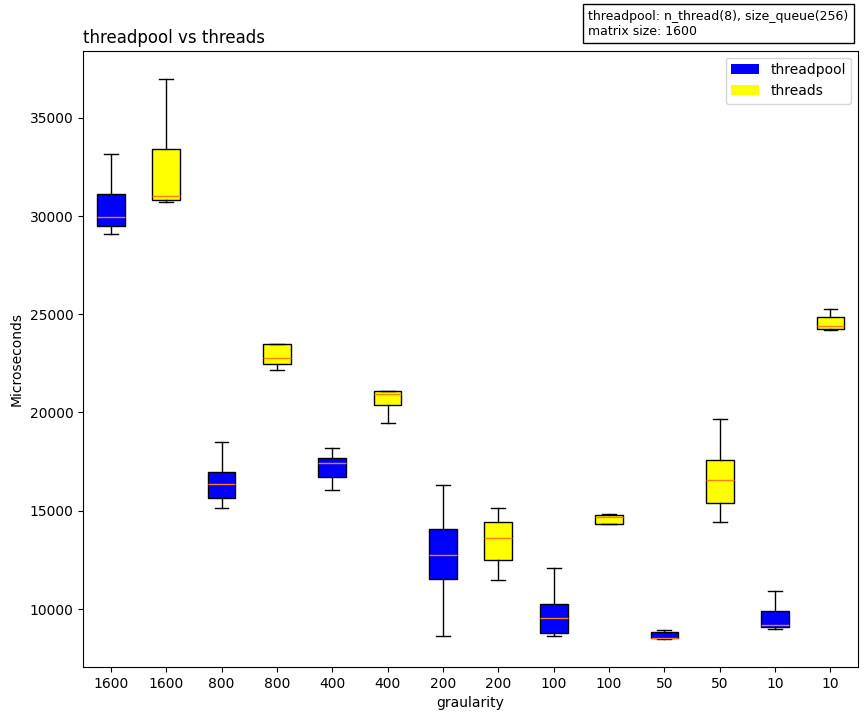

In [76]:
plot_granularity(dati_for, dati_parallel_for_sure_gran,"threadpool vs threads")



oss: sensato che quando total_job (= size/granularity) supera n_thread (qui da gran < 200) in threadpool si usufruisce du steal, in threads costi di inizializzazione di thread alzano